## Unlocking Real Estate Value: A Comprehensive EDA of House Prices

In [1]:
import pandas as pd

### Phase 1: Data Inseption & Structural Audit
1. Loading the dataset

In [2]:
train = pd.read_csv("train.csv")

In [4]:
train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [ ]:
train.shape
# returns num of rows & cols

(1460, 81)

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [9]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


missing value check

In [11]:
# isnull() returns true/false wheather any cell is missing

train.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [19]:
# extract data with conditions
# SalePrice: the property's sale price (dollars). This is the target variable that we're trying to predict
# GrLivArea: Above grade (ground) living area square feet
# OverallQual: Overall material and finish quality

expensive = train[train["SalePrice"] > 200000]
expensive[["SalePrice","OverallQual","GrLivArea","SaleType"]].head(10)

,SalePrice,OverallQual,GrLivArea,SaleType
0,208500,7,1710,WD
2,223500,7,1786,WD
4,250000,8,2198,WD
6,307000,8,1694,WD
11,345000,9,2324,New
13,279500,7,1494,New
20,325300,8,2376,New
22,230000,8,1795,WD
25,256300,8,1600,WD
27,306000,8,1704,WD


Aggregate using `groupby()`

In [ ]:
grp = train.groupby("OverallQual")["SalePrice"].mean()
# groupby().mean() look at the avg for each col separately
grp

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

### 2. Variable Categorization

In [34]:
num_Feature = train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_Feature = train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", num_Feature)
print("Categorical Features:", cat_Feature)

Numerical Features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categorical Features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Firepla

C:\Users\hp\AppData\Local\Temp\ipykernel_11344\3860345803.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_Feature = train.select_dtypes(include=["object"]).columns.tolist()


### 3. Target Variable analysis on `SalePrice`

In [31]:
print("Mean:", train["SalePrice"].mean().round(3))
print("Median:", train["SalePrice"].median().round(3))
print("Skewness:", train["SalePrice"].skew().round(3))
print("Kurtosis:", train["SalePrice"].kurtosis().round(3))

Mean: 180921.196
Median: 163000.0
Skewness: 1.883
Kurtosis: 6.536


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

4. Normal Distribution check

<Axes: xlabel='SalePrice', ylabel='Count'>

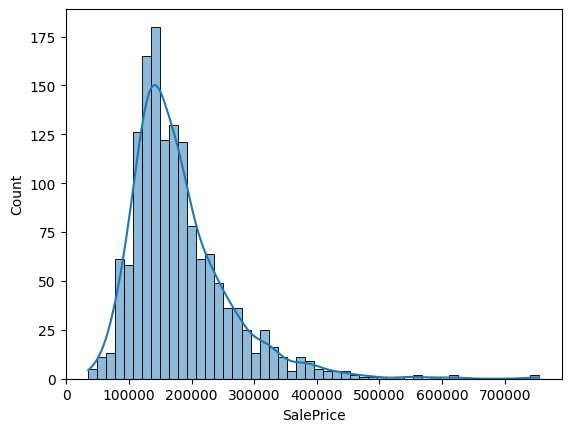

In [54]:
sns.histplot(train["SalePrice"], kde=True, bins=50)

Based on the histogram, this is a positively skewed distribution (right-skewed).

For right-skewed data, we need to do a log transformation.

((array([-3.30513952, -3.04793228, -2.90489705, ...,  2.90489705,
          3.04793228,  3.30513952], shape=(1460,)),
  array([ 34900,  35311,  37900, ..., 625000, 745000, 755000], shape=(1460,))),
 (np.float64(74160.16474519415),
  np.float64(180921.19589041095),
  np.float64(0.9319665641512986)))

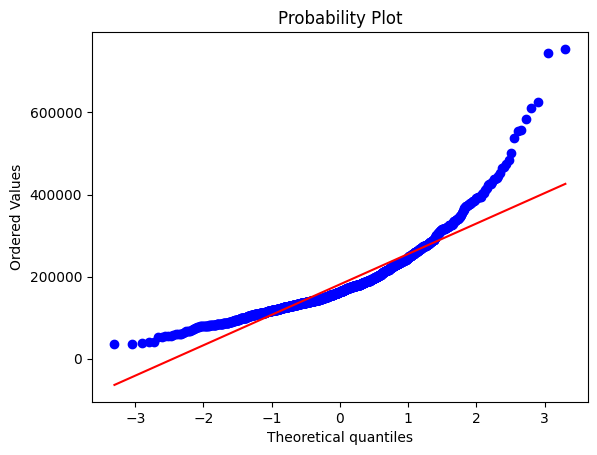

In [57]:
from scipy import stats
stats.probplot(train["SalePrice"], dist="norm", plot=plt)

From the QQ-plot, we can say that
1. Lower Quartiles: smaller house prices behave somewhat normally
2. Upper Quartiles: Larger house prices are much higher than expected under narmality.

* The most expensive houses are far from where they "should" be if the data were normal

5. Log transformation of `SalePrice`

In [60]:
import numpy as np
train["SalePrice_log"]=np.log(train["SalePrice"])


In [63]:
train[["SalePrice","SalePrice_log"]].head()

,SalePrice,SalePrice_log
0,208500,12.247694
1,181500,12.109011
2,223500,12.317167
3,140000,11.849398
4,250000,12.429216


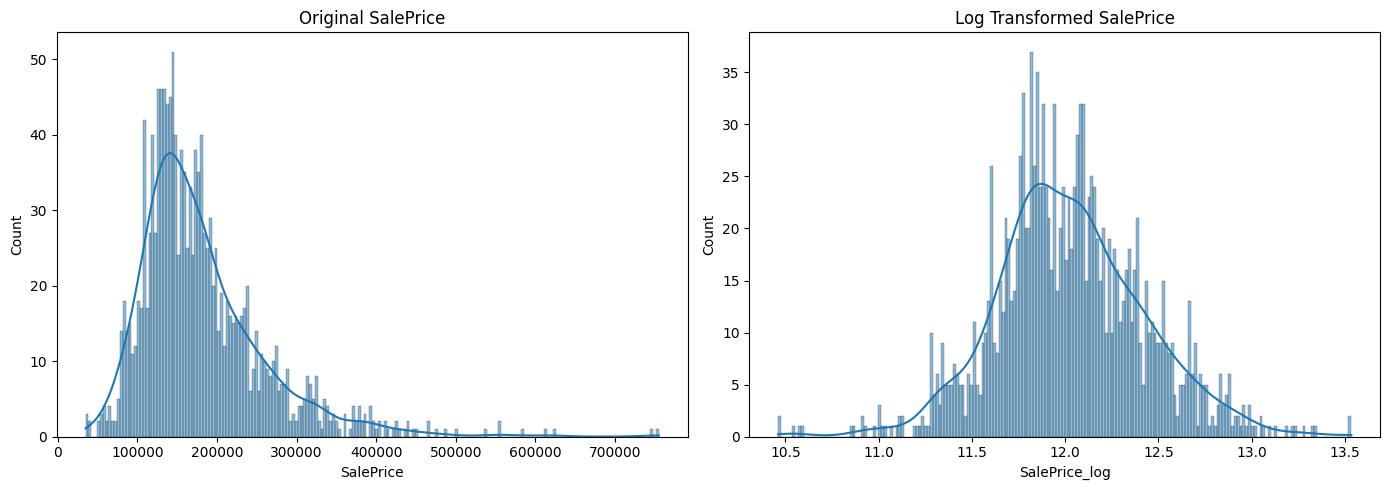

In [ ]:
# Compare distribution
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# original
sns.histplot(train["SalePrice"], kde=True, bins=200, ax=ax[0])
ax[0].set_title("Original SalePrice")

# log transformed
sns.histplot(train["SalePrice_log"], kde=True, bins=200, ax=ax[1])
ax[1].set_title("Log Transformed SalePrice")

plt.tight_layout()
plt.show()

In [ ]:
print("Skewness of Original SalePrice:", train["SalePrice"].skew().round(3))
print("Skewness of Log Transformed SalePrice:", train["SalePrice_log"].skew().round(3))

Skewness of Original SalePrice: 1.883
Skewness of Log Transformed SalePrice: 0.121


* Result: close to zero -> approximately normal. Almost 93% reduction.


### Phase 2: The "Cleaning" Ritual
- Missing value imputation
- Outlier treatment

1. Calculate Q1, Q3 and IQR

In [75]:
Q1 = train["SalePrice"].quantile(0.25)
Q3 = train["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 129975.0
Q3: 214000.0
IQR: 84025.0


2. Define bounds for outliers

In [76]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound for Outliers:", lower_bound)
print("Upper Bound for Outliers:", upper_bound)

Lower Bound for Outliers: 3937.5
Upper Bound for Outliers: 340037.5


3. Filter out the outliers

In [77]:
train2 = train[(train["SalePrice"] >= lower_bound) & (train["SalePrice"] <= upper_bound)]

print("Original data shape:", train.shape)
print("Cleaned data shape: ", train2.shape)
print("Num of outliers removed:", train.shape[0] - train2.shape[0])

Original data shape: (1460, 82)
Cleaned data shape:  (1399, 82)
Num of outliers removed: 61


4. Visualize boxplot before vs after outlier removal

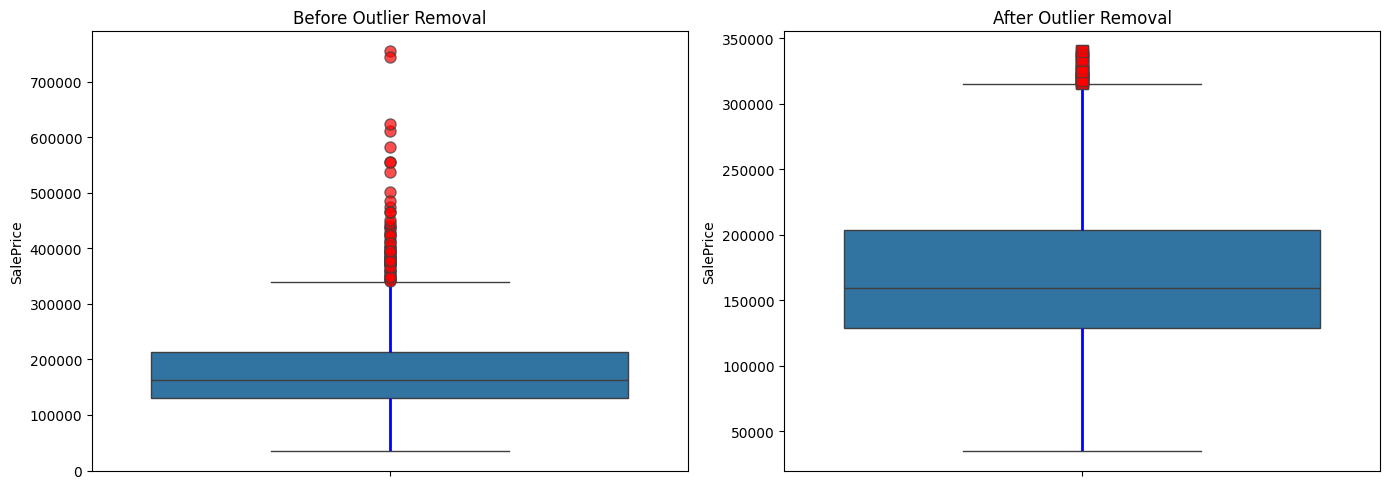

In [80]:
f, ax = plt.subplots(1, 2, figsize=(14,5))

# before
sns.boxplot(y=train["SalePrice"], ax=ax[0],whiskerprops=dict(linewidth=2, color='blue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none', alpha=0.7))
ax[0].set_title("Before Outlier Removal")
ax[0].set_ylabel("SalePrice")

#after
sns.boxplot(y=train2["SalePrice"], ax=ax[1],whiskerprops=dict(linewidth=2, color='blue'),
            flierprops=dict(marker='s', markerfacecolor='red', markersize=8, linestyle='none', alpha=0.7))
ax[1].set_title("After Outlier Removal")
ax[1].set_ylabel("SalePrice")

plt.tight_layout()
plt.show()



After outlier removal:
- very few outliers visible
- Shorter whiskers
- More symmetric box (median more centered within the box)
- Range now likely from ~50,000 to ~350,000